# W02 Pruning Notebook — Structured L1 Pruning Sweep + PELT
 
**Goal:** structured (channel-level) L1-norm pruning of the CIFAR-10
MobileNetV3-Small baseline (93.38% / 6.24 MB / 41 ms, ft3 session) across 
9 ratios (10%–90%), find the critical compression ratio with PELT 
changepoint detection, and explain the accuracy-collapse mechanism.
 
**Why torch-pruning instead of torch.nn.utils.prune:** the built-in utility
only zeroes weights (masks) — model size and latency don't change, so the
8-element table can't be filled. torch-pruning physically removes channels
and handles MobileNetV3's residual/SE dependency groups.
 
**Protocol (same as W01/quantization notebook):** seed 42, CPU, latency =
bs=1, 10 warmup + 100 runs. Each ratio is pruned independently from the
same baseline checkpoint (not cumulatively), so rows are comparable.
 
**How the sweep evolved:** first, a single-trial dependency-graph
validation (cells 4–6); then the 9-ratio zero-shot sweep (cells 7–8) —
the entire curve collapsed to ~random, which is itself the first finding
(no free redundancy) but leaves PELT nothing to detect (cells 9–11,
documented dead end). A small recovery probe (cells 12–13, 1ep×5k) showed
recovery is budget-limited, so the sweep was re-run unattended as a script
with a 12× budget (~6.5 h). The authoritative PELT and dual-axis figure
run on that ft3 data — final sections of this notebook.

Note on this saved run: it was executed under background load, so absolute
latencies read ~25–40% above the ft3/zero-shot sessions at low pruning
ratios and are comparable at high ratios; accuracy, size, and parameter
counts are load-independent and reproduce exactly. See also the note at
the end of Observations.

In [1]:
# --- Cell 1: run from repo root regardless of notebook location ----------
import os
from pathlib import Path
if Path.cwd().name == 'notebooks':
    os.chdir('..')
print('working dir:', Path.cwd())

# Reproducibility
import copy, json, random, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch_pruning as tp
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import mobilenet_v3_small

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print('torch', torch.__version__, '| torch-pruning', tp.__version__)

import logging
logging.getLogger('huggingface_hub').setLevel(logging.ERROR)

working dir: /Users/xsy/siyu-ingen-edge-ai
torch 2.12.1 | torch-pruning 1.6.0


In [2]:
# --- Cell 2: data (num_workers=0 - notebook + macOS spawn workaround) ----
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
TFM = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class HFCifar10(Dataset):
    def __init__(self, hf_split, tfm):
        self.ds, self.tfm = hf_split, tfm
    def __len__(self):
        return len(self.ds)
    def __getitem__(self, idx):
        item = self.ds[idx]
        return self.tfm(item['img']), item['label']

ds = load_dataset('uoft-cs/cifar10')
test_loader = DataLoader(HFCifar10(ds['test'], TFM), batch_size=128,
                         shuffle=False, num_workers=0)

# Small train subset for the optional short fine-tune.
ft_hf = ds['train'].shuffle(seed=SEED).select(range(5000))
ft_loader = DataLoader(HFCifar10(ft_hf, TFM), batch_size=64,
                       shuffle=True, num_workers=0)
print('test:', len(ds['test']), '| finetune subset:', len(ft_hf))

test: 10000 | finetune subset: 5000


In [3]:
# --- Cell 3: baseline model + metric helpers ---
CKPT = 'checkpoints/baseline_best.pth'

def build_model():
    m = mobilenet_v3_small(weights=None)
    m.classifier[3] = nn.Linear(1024, 10)
    return m

def load_baseline():
    m = build_model()
    m.load_state_dict(torch.load(CKPT, map_location='cpu'))
    m.eval()
    return m

Path('experiments').mkdir(exist_ok=True)

def model_size_mb(model):
    tmp = Path('experiments/_tmp_size.pth')
    torch.save(model.state_dict(), tmp)
    mb = tmp.stat().st_size / 1e6
    tmp.unlink()
    return mb

def measure_latency_ms(model, warmup=10, runs=100):
    x = torch.randn(1, 3, 224, 224)
    model.eval()
    times = []
    with torch.no_grad():
        for _ in range(warmup):
            model(x)
        for _ in range(runs):
            t0 = time.perf_counter()
            model(x)
            times.append((time.perf_counter() - t0) * 1000)
    return float(np.mean(times)), float(np.std(times))

def accuracy(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            correct += (model(x).argmax(1) == y).sum().item()
            total += y.numel()
    return correct / total

def profile(model, name, extra=None):
    row = {'config': name,
           'params': sum(p.numel() for p in model.parameters()),
           'test_acc': round(accuracy(model, test_loader), 4),
           'size_MB': round(model_size_mb(model), 2)}
    lat, lat_std = measure_latency_ms(model)
    row['latency_ms'] = round(lat, 2)
    row['latency_std_ms'] = round(lat_std, 2)
    if extra:
        row.update(extra)
    print(row)
    return row

fp32 = load_baseline()
print('baseline params:', sum(p.numel() for p in fp32.parameters()))

baseline params: 1528106


## Single-trial validation

Purpose: prove torch-pruning can traverse MobileNetV3-Small's dependency graph — residual adds and SE blocks force groups of layers to lose channels together. If `pruner.step()` survives and the forward pass still works, the 9-ratio sweep is just a loop.

`ignored_layers`: the final 10-class Linear must never be pruned (its output dimension IS the task).

In [4]:
# --- Cell 5: prune helper ---
def prune_model(ratio):
    """Load a fresh baseline and structurally prune `ratio` of channels
    using the L1 (magnitude) criterion. Returns the physically smaller model."""
    model = load_baseline()
    example = torch.randn(1, 3, 224, 224)
    importance = tp.importance.MagnitudeImportance(p=1)
    pruner = tp.pruner.MagnitudePruner(
        model, example, importance=importance,
        pruning_ratio=ratio,
        ignored_layers=[model.classifier[3]],
    )
    pruner.step()
    model.eval()
    return model

In [5]:
# --- Cell 6: 30% single trial (dependency-graph validation) ---
trial = prune_model(0.3)
with torch.no_grad():
    out = trial(torch.randn(1, 3, 224, 224))
print('forward OK:', out.shape)
print('params: baseline', sum(p.numel() for p in fp32.parameters()),
      '-> pruned', sum(p.numel() for p in trial.parameters()))
# Optional quick look (zero-shot, no fine-tune - accuracy WILL drop, that is expected):
# profile(trial, 'prune 30% zero-shot')

forward OK: torch.Size([1, 10])
params: baseline 1528106 -> pruned 762585


## 9-ratio sweep (zero-shot)

Each ratio prunes a fresh copy of the baseline. ~10–13 min per ratio on this machine (full test set + latency), ≈1.5–2h total — start it, then work on something else. Results stream into `experiments/W02_pruning_sweep.csv` after every ratio, so an interruption loses at most one row.

In [6]:
RATIOS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Zero-shot sweep: prune at each ratio, NO fine-tuning, profile all 4 metrics.
# Each ratio starts from the same baseline checkpoint (not cumulative).
sweep = [profile(fp32, 'baseline', extra={'ratio': 0.0})]
pd.DataFrame(sweep).to_csv('experiments/W02_pruning_sweep.csv', index=False)

for r in RATIOS:
    t0 = time.time()
    m = prune_model(r)
    row = profile(m, f'prune {int(r*100)}% zero-shot', extra={'ratio': r})
    sweep.append(row)
    pd.DataFrame(sweep).to_csv('experiments/W02_pruning_sweep.csv', index=False)
    print(f'  ratio {r} done in {(time.time()-t0)/60:.1f} min')

df_sweep = pd.DataFrame(sweep)
df_sweep

{'config': 'baseline', 'params': 1528106, 'test_acc': 0.9338, 'size_MB': 6.24, 'latency_ms': 39.21, 'latency_std_ms': 3.47, 'ratio': 0.0}
{'config': 'prune 10% zero-shot', 'params': 1240101, 'test_acc': 0.1504, 'size_MB': 5.08, 'latency_ms': 33.77, 'latency_std_ms': 0.62, 'ratio': 0.1}
  ratio 0.1 done in 2.1 min
{'config': 'prune 20% zero-shot', 'params': 986506, 'test_acc': 0.1123, 'size_MB': 4.06, 'latency_ms': 30.16, 'latency_std_ms': 0.49, 'ratio': 0.2}
  ratio 0.2 done in 1.4 min
{'config': 'prune 30% zero-shot', 'params': 762585, 'test_acc': 0.0763, 'size_MB': 3.16, 'latency_ms': 27.08, 'latency_std_ms': 0.96, 'ratio': 0.3}
  ratio 0.3 done in 1.2 min
{'config': 'prune 40% zero-shot', 'params': 566775, 'test_acc': 0.0996, 'size_MB': 2.37, 'latency_ms': 22.7, 'latency_std_ms': 0.97, 'ratio': 0.4}
  ratio 0.4 done in 1.0 min
{'config': 'prune 50% zero-shot', 'params': 403354, 'test_acc': 0.1054, 'size_MB': 1.72, 'latency_ms': 19.27, 'latency_std_ms': 0.23, 'ratio': 0.5}
  ratio 0.

,config,params,test_acc,size_MB,latency_ms,latency_std_ms,ratio
0,baseline,1528106,0.9338,6.24,39.21,3.47,0.0
1,prune 10% zero-shot,1240101,0.1504,5.08,33.77,0.62,0.1
2,prune 20% zero-shot,986506,0.1123,4.06,30.16,0.49,0.2
3,prune 30% zero-shot,762585,0.0763,3.16,27.08,0.96,0.3
4,prune 40% zero-shot,566775,0.0996,2.37,22.70,0.97,0.4
5,prune 50% zero-shot,403354,0.1054,1.72,19.27,0.23,0.5
6,prune 60% zero-shot,262541,0.0957,1.15,15.72,0.33,0.6
7,prune 70% zero-shot,153434,0.1000,0.71,12.09,0.09,0.7
8,prune 80% zero-shot,73045,0.1000,0.38,8.52,0.08,0.8
9,prune 90% zero-shot,21948,0.1000,0.17,4.89,0.21,0.9


## PELT on the zero-shot curve — a documented dead end
 
Project plan 1.4/5.3 hard requirement: the critical ratio must come from an
algorithm, not eyeballing. We treat the accuracy-vs-ratio sequence as a 1-D
signal and run PELT (`ruptures`, RBF cost).
 
**Why this first attempt cannot work:** the zero-shot curve drops to
~random at the very first ratio and stays flat (15.0% at 10%, ~10%
everywhere after). A changepoint detector needs régimes to separate; a
curve that is one long floor has no structure, so any breakpoint PELT
reports here reflects noise between near-identical segments, not a critical
compression ratio. The cells are kept (and still run) as a record of why
the recovery-budget rerun was necessary. **The authoritative PELT result
lives in the ft3 section at the end of this notebook.**

In [7]:
import ruptures as rpt

df = pd.read_csv('experiments/W02_pruning_sweep.csv')
signal = df['test_acc'].to_numpy().reshape(-1, 1)

# PELT with an RBF cost; pen controls sensitivity. With only 10 points,
# report the detected breakpoint AND sanity-check it against the curve.
algo = rpt.Pelt(model='rbf', min_size=2).fit(signal)
bkps = algo.predict(pen=1)
print('changepoint indices:', bkps)
for b in bkps[:-1]:   # last element is just len(signal)
    print(f'changepoint BEFORE ratio={df.iloc[b]["ratio"]:.1f} '
          f'(acc {df.iloc[b-1]["test_acc"]:.3f} -> {df.iloc[b]["test_acc"]:.3f})')

changepoint indices: [5, 10]
changepoint BEFORE ratio=0.5 (acc 0.100 -> 0.105)


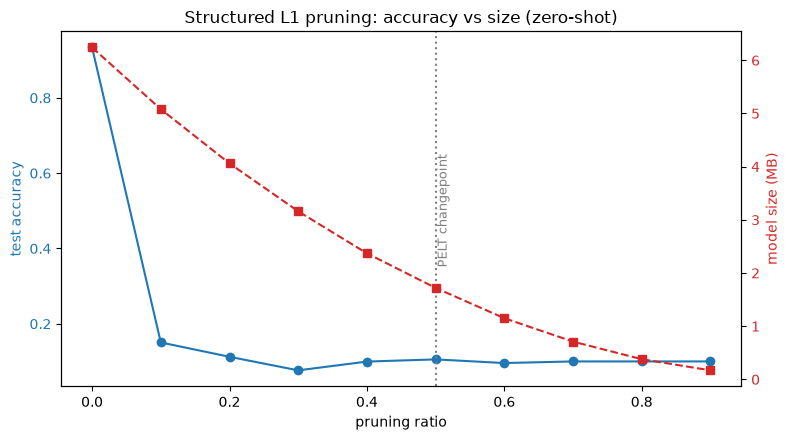

In [8]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(df['ratio'], df['test_acc'], 'o-', color='tab:blue', label='test acc')
ax1.set_xlabel('pruning ratio')
ax1.set_ylabel('test accuracy', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.plot(df['ratio'], df['size_MB'], 's--', color='tab:red', label='size (MB)')
ax2.set_ylabel('model size (MB)', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')

for b in bkps[:-1]:
    ax1.axvline(df.iloc[b]['ratio'], color='gray', ls=':', lw=1.5)
    ax1.annotate('PELT changepoint', xy=(df.iloc[b]['ratio'], 0.5),
                 rotation=90, va='center', fontsize=9, color='gray')

plt.title('Structured L1 pruning: accuracy vs size (zero-shot)')
fig.tight_layout()
plt.savefig('experiments/W02_pruning_curve.png', dpi=150)
plt.show()

## Recovery probe (1ep × 5k) — measuring the budget, not the model
 
Zero-shot pruning understates achievable accuracy, so we probe whether
short fine-tuning recovers it. Result: 1 epoch on 5k images lifts
10%-pruning only to 55.0%, and 20%+ stays at random. Diagnosis: the probe
measures the *recovery budget*, not the architecture — loss was still
falling when the epoch ended.
 
This motivated a rerun with a 12× budget
(`scripts/prune_ft_sweep.py`, 3 epochs × 20k images, all nine ratios,
results in `experiments/W02_pruning_sweep_ft3.csv`). A script rather than a
notebook cell: ~6.5 h of unattended running needs `nohup` + `caffeinate`
and per-ratio CSV checkpointing, none of which a notebook provides.

In [9]:
# Recovery probe: 1 epoch x 5k images per ratio - deliberately small budget,
# to test whether zero-shot numbers understate the model's true prunability.
def short_finetune(model, epochs=1, lr=1e-4):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    for ep in range(epochs):
        for x, y in ft_loader:
            opt.zero_grad()
            loss = crit(model(x), y)
            loss.backward()
            opt.step()
    model.eval()
    return model

ft_sweep = [profile(fp32, 'baseline', extra={'ratio': 0.0})]
pd.DataFrame(ft_sweep).to_csv('experiments/W02_pruning_sweep_ft.csv', index=False)

for r in RATIOS:
    t0 = time.time()
    m = short_finetune(prune_model(r), epochs=1)
    row = profile(m, f'prune {int(r*100)}% + 1ep ft', extra={'ratio': r})
    ft_sweep.append(row)
    pd.DataFrame(ft_sweep).to_csv('experiments/W02_pruning_sweep_ft.csv', index=False)
    print(f'  ratio {r} done in {(time.time()-t0)/60:.1f} min')

df_ft = pd.DataFrame(ft_sweep)
df_ft

{'config': 'baseline', 'params': 1528106, 'test_acc': 0.9338, 'size_MB': 6.24, 'latency_ms': 37.29, 'latency_std_ms': 1.06, 'ratio': 0.0}
{'config': 'prune 10% + 1ep ft', 'params': 1240101, 'test_acc': 0.5501, 'size_MB': 5.08, 'latency_ms': 33.61, 'latency_std_ms': 0.61, 'ratio': 0.1}
  ratio 0.1 done in 5.9 min
{'config': 'prune 20% + 1ep ft', 'params': 986506, 'test_acc': 0.1283, 'size_MB': 4.06, 'latency_ms': 30.21, 'latency_std_ms': 0.78, 'ratio': 0.2}
  ratio 0.2 done in 5.2 min
{'config': 'prune 30% + 1ep ft', 'params': 762585, 'test_acc': 0.1238, 'size_MB': 3.16, 'latency_ms': 26.58, 'latency_std_ms': 0.53, 'ratio': 0.3}
  ratio 0.3 done in 4.5 min
{'config': 'prune 40% + 1ep ft', 'params': 566775, 'test_acc': 0.0971, 'size_MB': 2.37, 'latency_ms': 22.9, 'latency_std_ms': 0.43, 'ratio': 0.4}
  ratio 0.4 done in 3.9 min
{'config': 'prune 50% + 1ep ft', 'params': 403354, 'test_acc': 0.1127, 'size_MB': 1.72, 'latency_ms': 19.37, 'latency_std_ms': 0.26, 'ratio': 0.5}
  ratio 0.5 don

,config,params,test_acc,size_MB,latency_ms,latency_std_ms,ratio
0,baseline,1528106,0.9338,6.24,37.29,1.06,0.0
1,prune 10% + 1ep ft,1240101,0.5501,5.08,33.61,0.61,0.1
2,prune 20% + 1ep ft,986506,0.1283,4.06,30.21,0.78,0.2
3,prune 30% + 1ep ft,762585,0.1238,3.16,26.58,0.53,0.3
4,prune 40% + 1ep ft,566775,0.0971,2.37,22.90,0.43,0.4
5,prune 50% + 1ep ft,403354,0.1127,1.72,19.37,0.26,0.5
6,prune 60% + 1ep ft,262541,0.1010,1.15,15.73,0.39,0.6
7,prune 70% + 1ep ft,153434,0.1000,0.71,12.18,0.55,0.7
8,prune 80% + 1ep ft,73045,0.1000,0.38,8.52,0.07,0.8
9,prune 90% + 1ep ft,21948,0.1000,0.17,4.91,0.23,0.9


## PELT on the ft3 curve (authoritative)
 
The 3ep×20k sweep produced a curve with real structure: 93.4 → 89.5 → 78.1
→ 68.0 → 56.6, then a slower tail down to 33.7 at 90%. PELT (RBF cost) is
swept across penalties and cross-checked with exact dynamic-programming
segmentation (Dynp, n_bkps=1) — with only 10 points, a single-penalty
answer would be fragile; agreement across penalties *and* across two
methods is the robustness criterion (project plan 5.3: stated criterion,
not eyeballing).
 
**Result: changepoint at nominal ratio 0.4 (test acc 56.60%).** Stable
across penalty ∈ [0.5, 2], no alternative location reported at any penalty,
independently confirmed by Dynp.
 
**Mechanism — read the changepoint correctly:** it separates steep collapse
(~10pt per step before 0.4) from saturation (~4–5pt per step after), i.e.
it marks where the damage is *complete*, not where it begins. By nominal
0.4, dependency-group coupling has physically removed 63% of parameters;
entire feature-detector groups are gone and accuracy approaches the
residual capacity floor. There is no pre-changepoint plateau: degradation
starts at the first step (10% already costs 3.9pt vs baseline). Unlike
over-parameterized networks, this curve has no free region — 0.4 is not a
"safe limit" but the point where little is left to destroy.

In [10]:
# PELT changepoint detection on the ft3 accuracy-vs-ratio curve.
# Method: changepoint must come from a stated criterion,
# not eyeballing. We run PELT (rbf cost) across a penalty sweep, then
# cross-check with Dynp (exact DP, n_bkps=1) - if both agree, the
# changepoint is robust, not an artifact of one penalty choice.
import ruptures as rpt

df = pd.read_csv('experiments/W02_pruning_sweep_ft3.csv')
ratios = df['ratio'].values
signal = df['test_acc'].values.reshape(-1, 1)

print("PELT (rbf) penalty sweep:")
for pen in [0.5, 1, 2, 3, 5, 10]:
    bkps = rpt.Pelt(model='rbf', min_size=2).fit(signal).predict(pen=pen)
    cps = [ratios[i - 1] for i in bkps[:-1]]   # last index is series end
    print(f"  pen={pen:>4}: changepoint ratio(s) = {cps}")

bkps_d = rpt.Dynp(model='rbf', min_size=2).fit(signal).predict(n_bkps=1)
cp_idx = bkps_d[0] - 1
print(f"\nDynp (exact, single changepoint): ratio = {ratios[cp_idx]}, "
      f"acc there = {signal[cp_idx][0]:.4f}")

PELT (rbf) penalty sweep:
  pen= 0.5: changepoint ratio(s) = [np.float64(0.4)]
  pen=   1: changepoint ratio(s) = [np.float64(0.4)]
  pen=   2: changepoint ratio(s) = [np.float64(0.4)]
  pen=   3: changepoint ratio(s) = []
  pen=   5: changepoint ratio(s) = []
  pen=  10: changepoint ratio(s) = []

Dynp (exact, single changepoint): ratio = 0.4, acc there = 0.5660


### Dual-axis figure
 
Accuracy + model size vs nominal ratio on the ft3 data, changepoint marked,
random-guess level (10%) shown for reference. Saved to
`experiments/W02_pruning_dualaxis_ft3.png` — this figure replaces the
zero-shot `W02_pruning_curve.png` as the Week 2 deliverable plot.

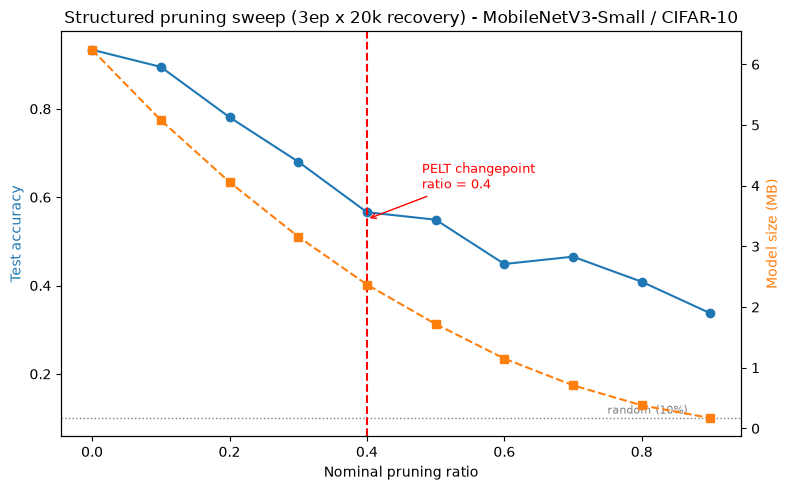

In [11]:
# Dual-axis plot: accuracy + size vs pruning ratio, changepoint marked.
cp_ratio = ratios[cp_idx]   # from the cell above; hardcode if you prefer

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(df['ratio'], df['test_acc'], 'o-', color='tab:blue', label='Test accuracy')
ax1.set_xlabel('Nominal pruning ratio')
ax1.set_ylabel('Test accuracy', color='tab:blue')
ax1.axhline(0.10, ls=':', color='gray', lw=1)
ax1.annotate('random (10%)', xy=(0.75, 0.11), color='gray', fontsize=8)

ax2 = ax1.twinx()
ax2.plot(df['ratio'], df['size_MB'], 's--', color='tab:orange', label='Model size (MB)')
ax2.set_ylabel('Model size (MB)', color='tab:orange')

ax1.axvline(cp_ratio, color='red', ls='--', lw=1.5)
ax1.annotate(f'PELT changepoint\nratio = {cp_ratio}', xy=(cp_ratio, 0.55),
             xytext=(cp_ratio + 0.08, 0.62), color='red', fontsize=9,
             arrowprops=dict(arrowstyle='->', color='red'))

ax1.set_title('Structured pruning sweep (3ep x 20k recovery) - MobileNetV3-Small / CIFAR-10')
fig.tight_layout()
fig.savefig('experiments/W02_pruning_dualaxis_ft3.png', dpi=150)
plt.show()

## Observations
 
**1. No free redundancy — the zero-shot collapse is the finding.**
Single-trial 30% confirmed torch-pruning traverses the dependency graph
cleanly, and exposed the nominal-vs-actual gap: dependency-group coupling
makes nominal 10% remove 18.8% of parameters, nominal 40% remove 63%, and
nominal 90% remove 98.6% (1,528,106 → 21,948). Zero-shot accuracy sits at
~random across the whole 10–90% range: MobileNetV3-Small, already
efficiency-optimized, carries no dormant channels to discard for free —
the opposite of the textbook over-parameterized-network result.
 
**2. Recovery is real but there is no loss-free region; changepoint = 0.4.**
The 12× budget rerun (3ep×20k) lifts 10%-pruning to 89.50% (vs 55.0% under
1ep×5k), proving the small-budget curve measured the budget. But even at
10% the model permanently loses 3.9pt, and the decline is monotone with no
plateau (the 60→70% uptick, 44.9→46.5, is fine-tuning noise at small
parameter counts). PELT places the changepoint at nominal 0.4 (56.60%),
penalty-stable and Dynp-confirmed — the saturation point of the collapse,
not its onset. Honest caveat: training loss was still falling at epoch 3
for every ratio, so ft3 accuracies are a lower bound under this budget;
the curve's shape and both conclusions are budget-robust, absolute values
are not.
 
**3. Size/latency gains are real; latency falls sub-linearly.** 50% → 1.72
MB, 90% → 0.17 MB; latency 41 ms → 34.2 ms (10%) → 7.1 ms (90%, all ft3 
session), with non-monotone bumps at low ratios (20%: 40.3 ms) from 
channel-count /memory-alignment interactions and bs=1 measurement noise 
— consistent with W01's memory-bound finding: parameters shrink faster 
than wall-clock time.
 
**4. Platform verdicts (full cross-technique analysis in the memo).**
Aido Rover (<5 MB, <100 ms): closest point is 10% pruning — 89.50% /
5.08 MB / 34.2 ms, 0.08 MB over budget; ~12% pruning would clear it
(extrapolated, not measured). Sentinel Prime (<3 MB): first pruning point
under 3 MB (40%, 2.37 MB) has 56.60% accuracy — not deployable; combined
with the INT8 accuracy collapse (quantization notebook), **no Week 2
technique reaches Sentinel**, which is the empirical case for Week 3
distillation.

**Hardware qualifier:** all latency figures are Apple M CPU numbers;
ratios transfer to Cortex-A class hardware, absolute values do not.

Note: this final rerun's absolute latencies ran ~25–40% above the earlier
ft3/zero-shot sessions at low pruning ratios and comparable at high ratios
(background load during measurement); accuracy, size, and parameter counts
are load-independent and reproduced exactly. Memo latency figures quote
the ft3/zero-shot sessions with noise flagged where applicable.